# Sentiment Analysis using Machine Learning

This notebook builds a sentiment analysis model using the uploaded dataset.

### Workflow
1. Load the dataset
2. Explore and check the data
3. Select text and sentiment columns
4. Split into training and testing data
5. Convert text into numerical features using TF-IDF
6. Train a Logistic Regression model
7. Evaluate the model
8. Test the model with new sentences


In [3]:
# Step 1 — Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [4]:
# Step 2 — Load the Dataset

df = pd.read_csv("sentiment_analysis.csv")

df.head()


,Year,Month,Day,Time of Tweet,text,sentiment,Platform
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook
2,2017,8,18,night,Don't angry me,negative,Facebook
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram


In [5]:
# Check dataset shape

df.shape


(499, 7)

In [6]:
# Check column names

df.columns


Index(['Year', 'Month', 'Day', 'Time of Tweet', 'text', 'sentiment',
       'Platform'],
      dtype='str')

In [7]:
# Step 3 — Check missing values

df.isna().sum()


Year             0
Month            0
Day              0
Time of Tweet    0
text             0
sentiment        0
Platform         0
dtype: int64

In [8]:
# Check sentiment distribution

df["sentiment"].value_counts()


sentiment
neutral     199
positive    166
negative    134
Name: count, dtype: int64

In [9]:
# Step 4 — Select input and target

X = df["text"]
y = df["sentiment"]

print("Input:")
print(X.head())

print("\nTarget:")
print(y.head())


Input:
0                What a great day!!! Looks like dream.
1       I feel sorry, I miss you here in the sea beach
2                                       Don't angry me
3    We attend in the class just for listening teac...
4                    Those who want to go, let them go
Name: text, dtype: str

Target:
0    positive
1    positive
2    negative
3    negative
4    negative
Name: sentiment, dtype: str


In [10]:
# Step 5 — Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (399,)
Testing data: (100,)


In [11]:
# Step 6 — Convert text into numerical features using TF-IDF

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)


Training TF-IDF shape: (399, 1072)
Testing TF-IDF shape: (100, 1072)


In [12]:
# Step 7 — Train Logistic Regression model

model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

print("Model training completed.")


Model training completed.


In [13]:
# Step 8 — Make predictions

y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])


['neutral' 'positive' 'negative' 'positive' 'neutral' 'neutral' 'negative'
 'positive' 'neutral' 'positive']


In [14]:
# Step 9 — Check accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy:", accuracy * 100, "%")


Accuracy: 0.69
Accuracy: 69.0 %


In [15]:
# Step 10 — Classification report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    negative       0.80      0.30      0.43        27
     neutral       0.61      0.95      0.75        40
    positive       0.82      0.70      0.75        33

    accuracy                           0.69       100
   macro avg       0.74      0.65      0.64       100
weighted avg       0.73      0.69      0.66       100



In [16]:
# Step 11 — Confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)


[[ 8 16  3]
 [ 0 38  2]
 [ 2  8 23]]


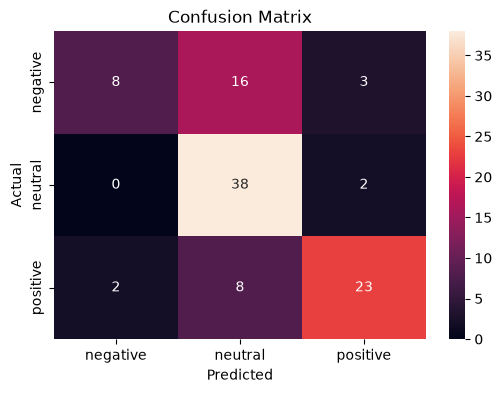

In [17]:
# Visualize confusion matrix

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [18]:
# Step 12 — Test the model with new sentences

new_text = [
    "I really enjoyed this product",
    "This is the worst experience ever",
    "I am very happy today",
    "I hate this service"
]

new_text_tfidf = tfidf.transform(new_text)

predictions = model.predict(new_text_tfidf)

for text, prediction in zip(new_text, predictions):
    print("Text:", text)
    print("Sentiment:", prediction)
    print()


Text: I really enjoyed this product
Sentiment: positive

Text: This is the worst experience ever
Sentiment: neutral

Text: I am very happy today
Sentiment: positive

Text: I hate this service
Sentiment: negative



In [19]:
import joblib

In [20]:
joblib.dump(model, "sentiment_model.pkl")

['sentiment_model.pkl']

In [21]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']